<a href="https://colab.research.google.com/github/sak-shi-collab/8_SAKSHI_D2/blob/main/rms_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("austinreese/craigslist-carstrucks-data")

print("Path to dataset files:", path)

100%|██████████| 262M/262M [00:14<00:00, 19.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/austinreese/craigslist-carstrucks-data/versions/10


In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
X = np.array([1,2,3,4,5,6,7,8,9,10], dtype=float)
y = np.array([8.5,7.8,7.0,6.3,5.7,5.0,4.4,3.9,3.5,3.0], dtype=float)


In [4]:
model = Sequential([
    Dense(8, activation='relu', input_shape=(1,)),
    Dense(4, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)



In [7]:
history = model.fit(
    X,
    y,
    epochs=1000,
    verbose=1
)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 936ms/step - loss: 33.5090 - mae: 5.5100
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 33.4742 - mae: 5.5068
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 33.4489 - mae: 5.5045
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 33.4278 - mae: 5.5026
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 33.4090 - mae: 5.5009
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 33.3918 - mae: 5.4994
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 33.3758 - mae: 5.4979
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 33.3606 - mae: 5.4965
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 33.3460 - mae: 5.4952
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 33.3320 - mae: 5.4939
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 33.3184 - mae: 5.4927
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 33.3052 - mae: 5.4915
Epoch 13/1000
1/1 ━━━━━━

In [8]:
new_car = np.array([[12]])

predicted_price = model.predict(new_car)

print("Predicted Selling Price for 12-year-old car: ₹{:.2f} Lakhs"
      .format(predicted_price[0][0]))



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted Selling Price for 12-year-old car: ₹1.01 Lakhs


In [9]:
predictions = model.predict(X)


plt.figure(figsize=(8,5))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

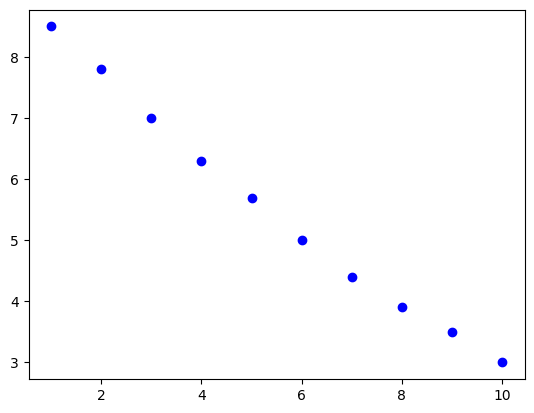

In [10]:
plt.scatter(
    X,
    y,
    color='blue',
    label='Actual Price'
)


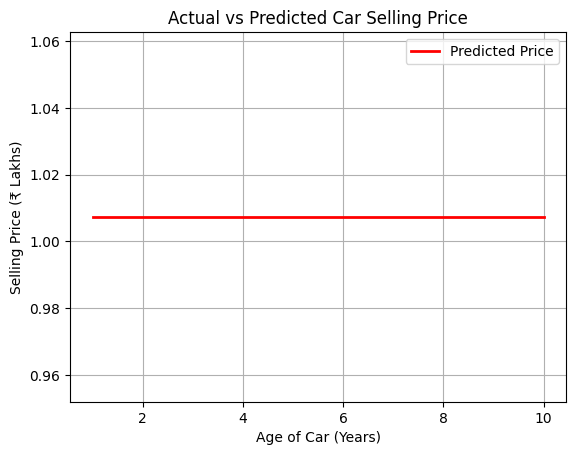

In [11]:
plt.plot(
    X,
    predictions,
    color='red',
    linewidth=2,
    label='Predicted Price'
)

plt.title("Actual vs Predicted Car Selling Price")
plt.xlabel("Age of Car (Years)")
plt.ylabel("Selling Price (₹ Lakhs)")
plt.legend()
plt.grid(True)

In [12]:
plt.show()


# ---------------------------------
# Display Final MAE
# ---------------------------------

loss, mae = model.evaluate(X, y, verbose=0)

print("Mean Absolute Error (MAE): {:.4f} Lakhs".format(mae))

Mean Absolute Error (MAE): 4.5026 Lakhs


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


TypeError: scatter() got multiple values for argument 's'

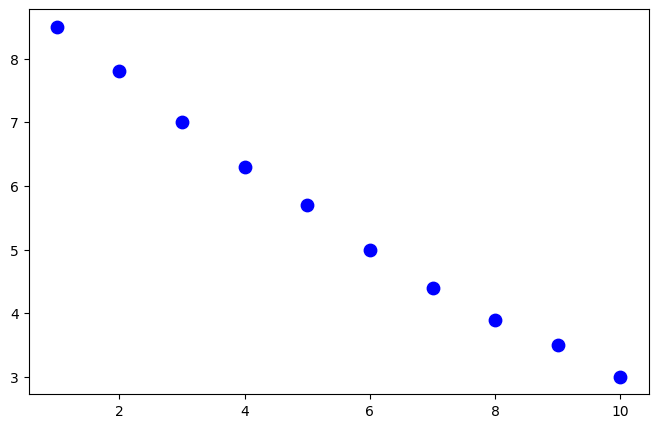

In [16]:
# ---------------------------------
# Actual vs Predicted Plot
# ---------------------------------

predictions = model.predict(X)

plt.figure(figsize=(8,5))

# Plot Actual values
plt.scatter(
    X,
    y,
    color='blue',
    s=80,
    label='Actual Values'
)

# Plot Predicted values
plt.scatter(
    X,
    y,
    predictions,
    color='red',
    s=80,
    label='Predicted Values'
)

plt.title("Actual vs Predicted Car Selling Price")
plt.xlabel("Age of Car (Years)")
plt.ylabel("Selling Price (₹ Lakhs)")

plt.legend()
plt.grid(True)

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


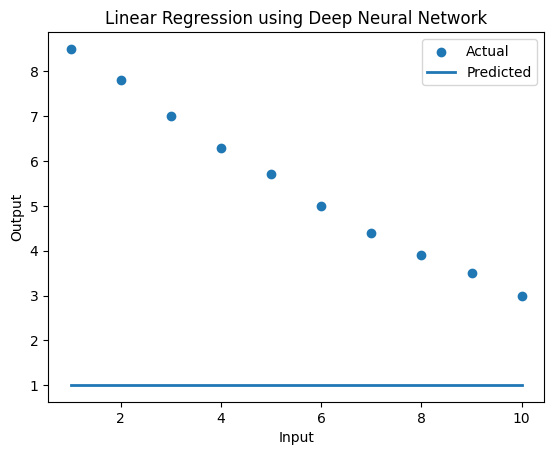

In [15]:
pred = model.predict(X)
plt.scatter(X, y, label="Actual")
plt.plot(X, pred, linewidth=2, label="Predicted")
plt.xlabel("Input")
plt.ylabel("Output")
plt.title("Linear Regression using Deep Neural Network")
plt.legend()
plt.show()


In [17]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

In [18]:
X = np.array([1,2,3,4,5,6,7,8,9,10], dtype=float).reshape(-1,1)

y = np.array([8.5,7.8,7.0,6.3,5.7,5.0,4.4,3.9,3.5,3.0], dtype=float)

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
model = Sequential([
    Dense(8, activation='relu', input_shape=(1,)),
    Dense(4, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [22]:
model.fit(
    X_scaled,
    y,
    epochs=1000,
    verbose=0
)


In [23]:
predictions = model.predict(X_scaled)


predictions = predictions.flatten()



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


In [24]:
new_car = np.array([[12]])
new_car_scaled = scaler.transform(new_car)

price = model.predict(new_car_scaled)

print("Predicted price for 12-year-old car: ₹{:.2f} Lakhs".format(price[0][0]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted price for 12-year-old car: ₹2.75 Lakhs


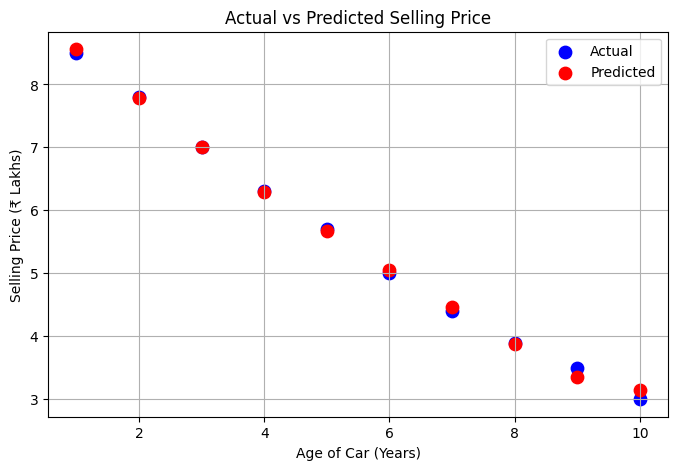

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(
    X,
    y,
    color='blue',
    s=80,
    label='Actual'
)

plt.scatter(
    X,
    predictions,
    color='red',
    s=80,
    label='Predicted'
)

plt.xlabel("Age of Car (Years)")
plt.ylabel("Selling Price (₹ Lakhs)")
plt.title("Actual vs Predicted Selling Price")

plt.legend()
plt.grid(True)

plt.show()